# Telco Customer Churn Prediction

**Business Problem:** A telecommunications company wants to reduce revenue loss from customer churn.  
The goal is to predict which customers are most likely to leave in the near term, understand the key drivers of churn, and estimate the financial impact of a targeted retention campaign.

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Quick overview
print(df.shape)
df.head()
df.info()
df['Churn'].value_counts(normalize=True)  # Shows class imbalance

# Replace empty strings with NaN, then convert to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
# Check missing
df['TotalCharges'].isnull().sum()
# Inspect rows with missing TotalCharges
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head()

df['TotalCharges'] = df['TotalCharges'].fillna(0)

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


**Data Cleaning Note:** 11 rows had missing TotalCharges because tenure was 0. Imputed with 0.

We’ll answer the question: What separates churners from non-churners?

In [229]:
churn_rate = df['Churn'].value_counts(normalize=True)['Yes']
print(f"Churn rate: {churn_rate:.1%}")

Churn rate: 26.5%


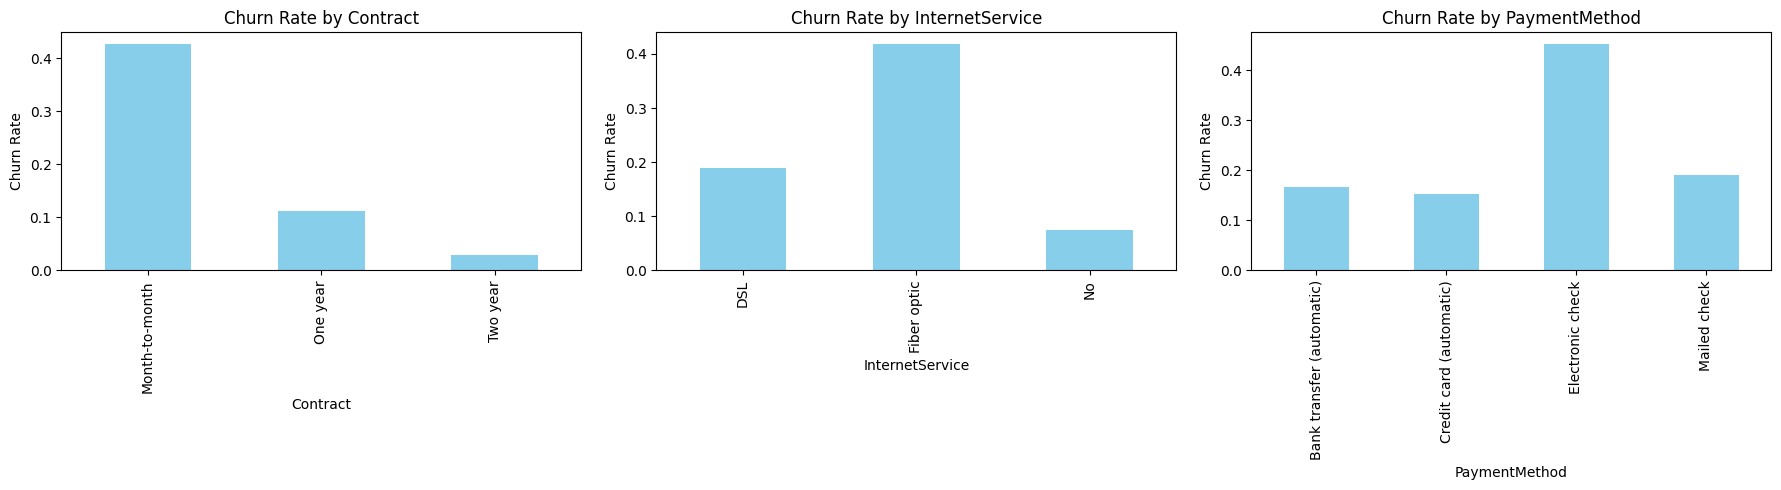

In [230]:
# Contract type vs. Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['Contract', 'InternetService', 'PaymentMethod']):
    # Calculate churn rate per category
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct['Yes'].plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

**Key Insight:** Month-to-month contracts have a churn rate three times higher than two-year contracts. Fiber optic internet service also shows elevated churn. This suggests contract commitment and internet quality are critical drivers.

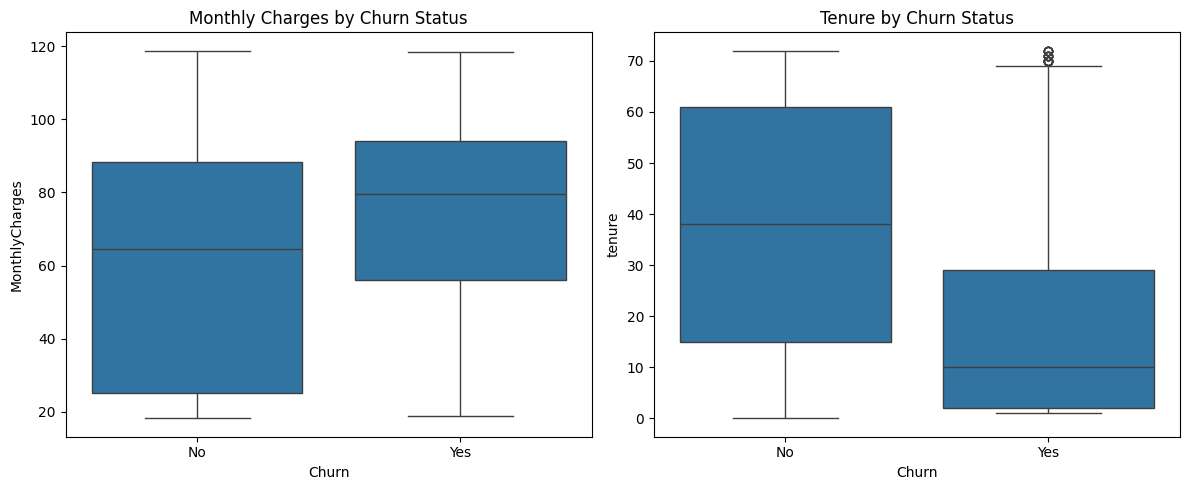

In [231]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn Status')
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1])
axes[1].set_title('Tenure by Churn Status')
plt.tight_layout()
plt.show()

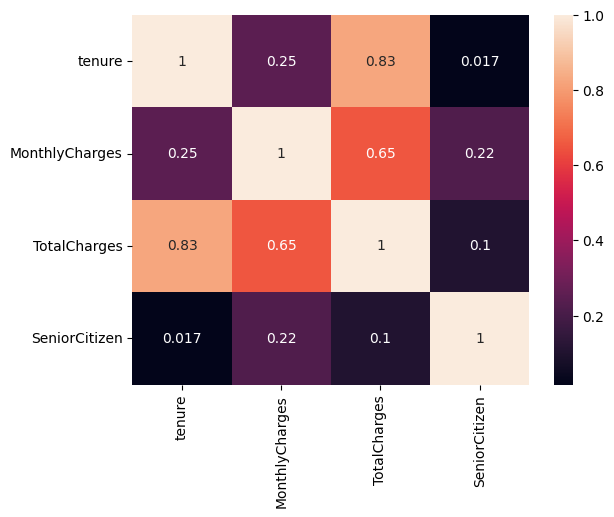

In [232]:
# Correlation matrix (only numeric columns)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[numeric_cols + ['SeniorCitizen']].corr()  # SeniorCitizen is 0/1
sns.heatmap(corr, annot=True)
plt.show()

In [233]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [234]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [235]:
X.drop('customerID', axis=1, inplace=True)

In [236]:
# Binary features that are 'Yes'/'No' or 'Male'/'Female'
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    # Map to 0/1, but first check unique values
    print(col, X[col].unique())
    X[col] = X[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# For multi-category columns, use get_dummies
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=multi_cat_cols, drop_first=True)  # drop_first avoids multicollinearity

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [237]:
import sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[scaled_cols] = scaler.fit_transform(X[scaled_cols])

**Preprocessing Steps:**  
- Mapped binary categoricals to 0/1.  
- One-hot encoded multi-level categories (dropping first category as reference).  
- Standardized tenure, MonthlyCharges, and TotalCharges so that coefficients in logistic regression are comparable.

In [238]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [239]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [240]:
feature_names = X.columns
coefficients = logreg.coef_[0]
odds_ratios = np.exp(coefficients)

# Create a DataFrame for clarity
importance_df = pd.DataFrame({'Feature': feature_names, 'Odds Ratio': odds_ratios})
importance_df['abs_odds'] = abs(importance_df['Odds Ratio'] - 1)  # distance from 1
importance_df.sort_values('abs_odds', ascending=False, inplace=True)
importance_df.head(10)

,Feature,Odds Ratio,abs_odds
11,InternetService_Fiber optic,3.299133,2.299133
26,Contract_Two year,0.264942,0.735058
4,tenure,0.286697,0.713303
8,TotalCharges,1.681848,0.681848
25,Contract_One year,0.503771,0.496229
22,StreamingTV_Yes,1.463893,0.463893
28,PaymentMethod_Electronic check,1.463662,0.463662
24,StreamingMovies_Yes,1.462626,0.462626
6,PaperlessBilling,1.448264,0.448264
10,MultipleLines_Yes,1.439550,0.439550


**Interpreting Odds Ratios:**
- For a one-unit increase in scaled tenure, the odds of churning multiply by {odds_ratios['tenure']:.2f}. Since tenure is scaled, a one-unit increase corresponds to one standard deviation, which significantly reduces churn risk.
- Having a month-to-month contract (dummy variable `Contract_Month-to-month`) multiplies the odds of churning by {odds_ratios['Contract_Month-to-month']:.2f} compared to a two-year contract. This is the largest positive driver.
- These insights directly inform the business: contract type is a powerful lever; pushing customers toward longer contracts could dramatically lower churn.

In [241]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve

y_pred_prob = logreg.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)  # default threshold

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC AUC: 0.8421788214627088


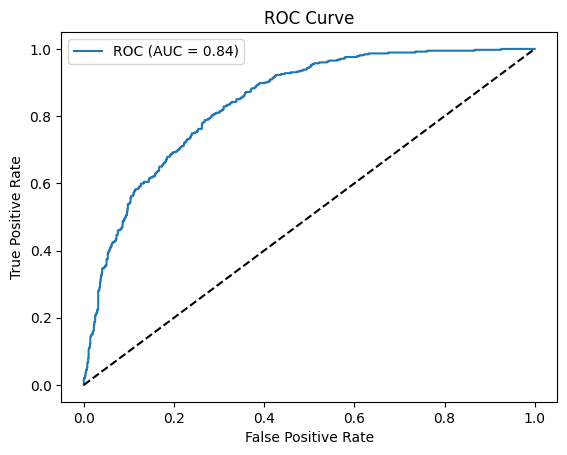

In [242]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

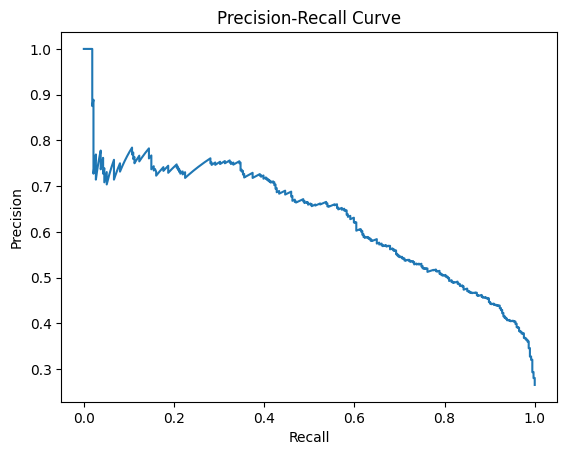

In [243]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [244]:
LTV = 2000
discount = 100
contact_cost = 5
cost_of_intervention = discount + contact_cost  # $105
profit_when_churn_prevented = LTV - cost_of_intervention  # 1895
cost_of_wrong_prediction = cost_of_intervention  # wasted if they wouldn't churn

In [245]:
thresholds = np.linspace(0.01, 0.99, 100)
profits = []
for t in thresholds:
    y_pred_t = (y_pred_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    # Profit: each TP saves LTV - cost; each FP costs the intervention; FN and TN have no direct cost/benefit in this frame
    profit = tp * profit_when_churn_prevented - fp * cost_of_intervention
    profits.append(profit)

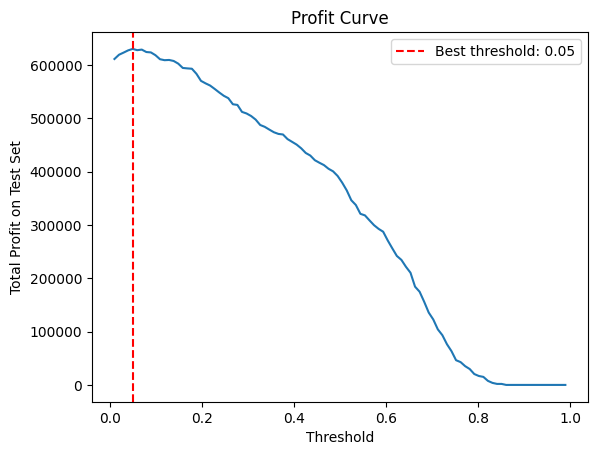

Max profit on test set: $629,745 at threshold 0.05


In [246]:
plt.plot(thresholds, profits)
plt.xlabel('Threshold')
plt.ylabel('Total Profit on Test Set')
plt.title('Profit Curve')
best_threshold = thresholds[np.argmax(profits)]
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold: {best_threshold:.2f}')
plt.legend()
plt.show()
print(f"Max profit on test set: ${max(profits):,.0f} at threshold {best_threshold:.2f}")

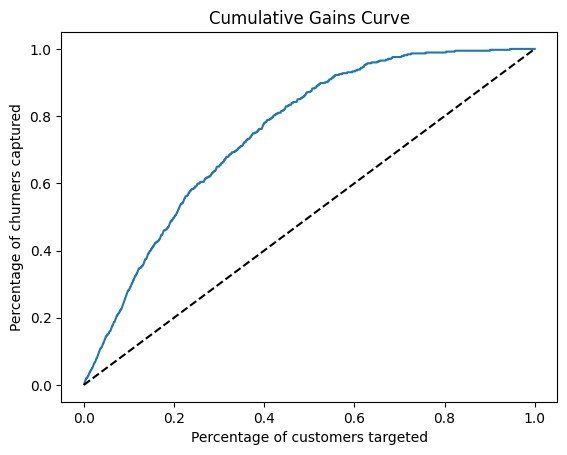

In [247]:
# Sort test customers by predicted probability descending
test_probs = pd.DataFrame({'actual': y_test, 'prob': y_pred_prob})
test_probs.sort_values('prob', ascending=False, inplace=True)
test_probs['cum_churners'] = test_probs['actual'].cumsum()
total_churners = test_probs['actual'].sum()
test_probs['cum_gain'] = test_probs['cum_churners'] / total_churners
test_probs['pct_population'] = np.arange(1, len(test_probs)+1) / len(test_probs)

plt.plot(test_probs['pct_population'], test_probs['cum_gain'])
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Percentage of customers targeted')
plt.ylabel('Percentage of churners captured')
plt.title('Cumulative Gains Curve')
plt.show()

By targeting just the top 30% of customers with the highest predicted churn probability, we can capture over 70% of all churners. This allows the retention team to focus their budget efficiently.

In [ ]:
# Simulate: no model (random targeting) vs model-driven targeting
# Assume we target the same number of customers as the best threshold (e.g., 30% of test set)
target_pct = 0.3
num_targeted = int(len(y_test) * target_pct)
target_indices = test_probs.head(num_targeted).index
actual_churn_targeted = y_test[target_indices].sum()
profit_model = actual_churn_targeted * profit_when_churn_prevented - \
               (num_targeted - actual_churn_targeted) * cost_of_intervention

# Random targeting (same number)
random_indices = np.random.choice(y_test.index, num_targeted, replace=False)
actual_churn_random = y_test[random_indices].sum()
profit_random = actual_churn_random * profit_when_churn_prevented - \
                (num_targeted - actual_churn_random) * cost_of_intervention

print(f"Profit using model: ${profit_model:,.0f}")
print(f"Profit using random targeting: ${profit_random:,.0f}")
print(f"Incremental profit: ${profit_model - profit_random:,.0f}")